In [18]:
# CELLULE 1 - Imports et chargement des données preprocessées
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, f1_score, recall_score,
                             precision_score, accuracy_score,
                             RocCurveDisplay, PrecisionRecallDisplay)
from sklearn.model_selection import StratifiedKFold, cross_val_score
import joblib
import warnings
warnings.filterwarnings('ignore')

COLOR_BLUE  = "#163767"
COLOR_RED   = "#E53935"
COLOR_GREEN = "#43A047"

# Chargement des données preprocessées
X_train = np.load('../data/processed/X_train.npy')
X_test  = np.load('../data/processed/X_test.npy')
y_train = np.load('../data/processed/y_train.npy')
y_test  = np.load('../data/processed/y_test.npy')

print(f"X_train : {X_train.shape} | X_test : {X_test.shape}")
print(f"Proportion pannes train : {y_train.mean():.1%}")

X_train : (19233, 14) | X_test : (4809, 14)
Proportion pannes train : 14.8%


In [19]:
# CELLULE 2 - Fonction d'évaluation commune
def evaluate_model(name, model, X_test, y_test, results={}):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    results[name] = {
        'Accuracy':  accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall':    recall_score(y_test, y_pred),
        'F1':        f1_score(y_test, y_pred),
        'ROC-AUC':   roc_auc_score(y_test, y_proba)
    }
    
    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(classification_report(y_test, y_pred, 
          target_names=['Pas de panne', 'Panne']))
    print(f"ROC-AUC : {results[name]['ROC-AUC']:.4f}")
    
    return results

results = {}
print("Fonction d'évaluation prête")

Fonction d'évaluation prête


In [20]:
# CELLULE 3 - Modele 1 : Logistic Regression (baseline)
lr = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')
lr.fit(X_train, y_train)

results = evaluate_model('Logistic Regression', lr, X_test, y_test, results)

joblib.dump(lr, '../models/logistic_regression.joblib')


  Logistic Regression
              precision    recall  f1-score   support

Pas de panne       0.98      0.91      0.95      4097
       Panne       0.64      0.89      0.75       712

    accuracy                           0.91      4809
   macro avg       0.81      0.90      0.85      4809
weighted avg       0.93      0.91      0.92      4809

ROC-AUC : 0.9588


['../models/logistic_regression.joblib']

In [21]:
# CELLULE 4 - Modele 2 : Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42, 
                             class_weight='balanced', n_jobs=-1)
rf.fit(X_train, y_train)

results = evaluate_model('Random Forest', rf, X_test, y_test, results)

joblib.dump(rf, '../models/random_forest.joblib')


  Random Forest
              precision    recall  f1-score   support

Pas de panne       0.98      0.98      0.98      4097
       Panne       0.90      0.88      0.89       712

    accuracy                           0.97      4809
   macro avg       0.94      0.93      0.94      4809
weighted avg       0.97      0.97      0.97      4809

ROC-AUC : 0.9938


['../models/random_forest.joblib']

In [23]:
import subprocess
import sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'xgboost'])

0

In [24]:
# CELLULE 5 - Modele 3 : Gradient Boosting (XGBoost)
from xgboost import XGBClassifier

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb = XGBClassifier(n_estimators=100, random_state=42,
                    scale_pos_weight=scale_pos_weight,
                    eval_metric='logloss', verbosity=0)
xgb.fit(X_train, y_train)

results = evaluate_model('XGBoost', xgb, X_test, y_test, results)

joblib.dump(xgb, '../models/xgboost.joblib')


  XGBoost
              precision    recall  f1-score   support

Pas de panne       0.99      0.98      0.98      4097
       Panne       0.88      0.96      0.92       712

    accuracy                           0.97      4809
   macro avg       0.94      0.97      0.95      4809
weighted avg       0.98      0.97      0.97      4809

ROC-AUC : 0.9955


['../models/xgboost.joblib']

In [25]:
import subprocess
import sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'tensorflow'])

0

In [27]:
# CELLULE 6 - Modele 4 : MLP (Deep Learning)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

model_mlp = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    BatchNormalization(),
    Dropout(0.3),
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

model_mlp.compile(optimizer=Adam(learning_rate=0.001),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Poids des classes pour gérer le déséquilibre
class_weight = {0: 1.0, 1: (y_train == 0).sum() / (y_train == 1).sum()}

history = model_mlp.fit(X_train, y_train,
                        epochs=100,
                        batch_size=256,
                        validation_split=0.2,
                        class_weight=class_weight,
                        callbacks=[early_stop],
                        verbose=1)

Epoch 1/100
61/61 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7254 - loss: 0.8293 - val_accuracy: 0.9127 - val_loss: 0.4957
Epoch 2/100
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8814 - loss: 0.5304 - val_accuracy: 0.9257 - val_loss: 0.3364
Epoch 3/100
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8989 - loss: 0.4613 - val_accuracy: 0.9259 - val_loss: 0.2682
Epoch 4/100
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9017 - loss: 0.4210 - val_accuracy: 0.9337 - val_loss: 0.2102
Epoch 5/100
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9092 - loss: 0.3994 - val_accuracy: 0.9233 - val_loss: 0.2115
Epoch 6/100
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9125 - loss: 0.3792 - val_accuracy: 0.9322 - val_loss: 0.1800
Epoch 7/100
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9147 - loss: 0.3655 - val_accuracy: 0.9322 - val_loss: 0.1674
Epoch 8/100
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9163 - loss: 0.3475 - val_accuracy: 0.9262 - v

In [28]:
print("MLP termine !")
print(f"Nombre d'epochs effectues : {len(history.history['loss'])}")

MLP termine !
Nombre d'epochs effectues : 17


In [29]:
# CELLULE 7 - Evaluation MLP
from sklearn.metrics import classification_report, roc_auc_score

y_proba_mlp = model_mlp.predict(X_test, verbose=0).flatten()
y_pred_mlp = (y_proba_mlp >= 0.5).astype(int)

results['MLP'] = {
    'Accuracy':  accuracy_score(y_test, y_pred_mlp),
    'Precision': precision_score(y_test, y_pred_mlp),
    'Recall':    recall_score(y_test, y_pred_mlp),
    'F1':        f1_score(y_test, y_pred_mlp),
    'ROC-AUC':   roc_auc_score(y_test, y_proba_mlp)
}

print("MLP (Deep Learning)")
print("="*50)
print(classification_report(y_test, y_pred_mlp,
      target_names=['Pas de panne', 'Panne']))
print(f"ROC-AUC : {results['MLP']['ROC-AUC']:.4f}")

model_mlp.save('../models/mlp_model.keras')
print("Modele sauvegarde")

MLP (Deep Learning)
              precision    recall  f1-score   support

Pas de panne       0.98      0.94      0.96      4097
       Panne       0.71      0.90      0.79       712

    accuracy                           0.93      4809
   macro avg       0.85      0.92      0.88      4809
weighted avg       0.94      0.93      0.93      4809

ROC-AUC : 0.9743
Modele sauvegarde


COMPARAISON DES 4 MODELES
                     Accuracy  Precision  Recall      F1  ROC-AUC
XGBoost                0.9744     0.8820  0.9551  0.9171   0.9955
Random Forest          0.9682     0.9010  0.8820  0.8914   0.9938
MLP                    0.9310     0.7111  0.8989  0.7940   0.9743
Logistic Regression    0.9102     0.6408  0.8947  0.7468   0.9588


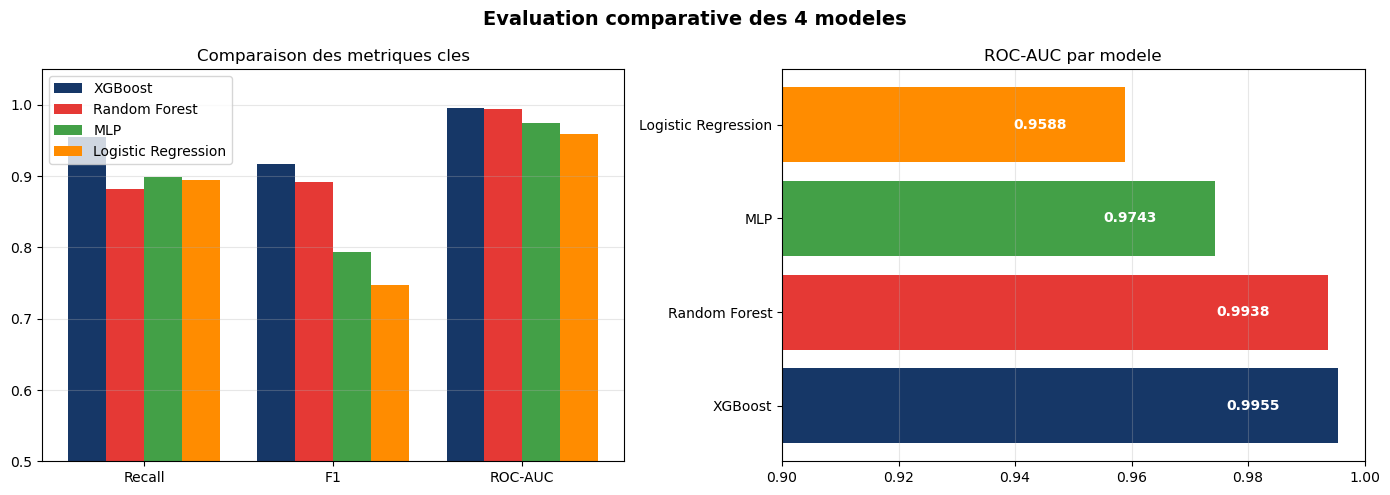

In [30]:
# CELLULE 8 - Tableau comparatif des 4 modeles
df_results = pd.DataFrame(results).T.round(4)
df_results = df_results.sort_values('ROC-AUC', ascending=False)

print("COMPARAISON DES 4 MODELES")
print("="*60)
print(df_results.to_string())

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

metrics = ['Recall', 'F1', 'ROC-AUC']
x = np.arange(len(metrics))
width = 0.2
colors = [COLOR_BLUE, COLOR_RED, COLOR_GREEN, '#FF8C00']
models = list(df_results.index)

for i, (model, color) in enumerate(zip(models, colors)):
    vals = [df_results.loc[model, m] for m in metrics]
    axes[0].bar(x + i*width, vals, width, label=model, color=color)

axes[0].set_xticks(x + width*1.5)
axes[0].set_xticklabels(metrics)
axes[0].set_ylim(0.5, 1.05)
axes[0].set_title('Comparaison des metriques cles')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# ROC-AUC seul
roc_vals = [df_results.loc[m, 'ROC-AUC'] for m in models]
bars = axes[1].barh(models, roc_vals, color=colors)
for bar, val in zip(bars, roc_vals):
    axes[1].text(bar.get_width() - 0.01, bar.get_y() + bar.get_height()/2,
                 f'{val:.4f}', va='center', ha='right', 
                 color='white', fontweight='bold')
axes[1].set_xlim(0.9, 1.0)
axes[1].set_title('ROC-AUC par modele')
axes[1].grid(axis='x', alpha=0.3)

plt.suptitle('Evaluation comparative des 4 modeles', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [31]:
# CELLULE 9 - Gestion du déséquilibre : SMOTE + Undersampling
from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler

# Baseline sans rééchantillonnage (déjà fait - XGBoost)
print("Distribution originale:")
unique, counts = np.unique(y_train, return_counts=True)
print(dict(zip(unique, counts)))

# SMOTE
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
print(f"\nApres SMOTE:")
unique, counts = np.unique(y_train_smote, return_counts=True)
print(dict(zip(unique, counts)))

# Random Over-Sampling
ros = RandomOverSampler(random_state=42)
X_train_ros, y_train_ros = ros.fit_resample(X_train, y_train)
print(f"\nApres Random Over-Sampling:")
unique, counts = np.unique(y_train_ros, return_counts=True)
print(dict(zip(unique, counts)))

# Random Under-Sampling
rus = RandomUnderSampler(random_state=42)
X_train_rus, y_train_rus = rus.fit_resample(X_train, y_train)
print(f"\nApres Random Under-Sampling:")
unique, counts = np.unique(y_train_rus, return_counts=True)
print(dict(zip(unique, counts)))

Distribution originale:
{np.int64(0): np.int64(16385), np.int64(1): np.int64(2848)}

Apres SMOTE:
{np.int64(0): np.int64(16385), np.int64(1): np.int64(16385)}

Apres Random Over-Sampling:
{np.int64(0): np.int64(16385), np.int64(1): np.int64(16385)}

Apres Random Under-Sampling:
{np.int64(0): np.int64(2848), np.int64(1): np.int64(2848)}


In [32]:
# CELLULE 10 - Comparaison des techniques de rééquilibrage avec XGBoost
results_imbalance = {}

# 1. Baseline (class_weight='balanced')
xgb_base = XGBClassifier(n_estimators=100, random_state=42,
                         scale_pos_weight=16385/2848,
                         eval_metric='logloss', verbosity=0)
xgb_base.fit(X_train, y_train)
y_pred = xgb_base.predict(X_test)
y_proba = xgb_base.predict_proba(X_test)[:,1]
results_imbalance['Baseline (class_weight)'] = {
    'Recall': recall_score(y_test, y_pred),
    'F1': f1_score(y_test, y_pred),
    'ROC-AUC': roc_auc_score(y_test, y_proba)
}

# 2. SMOTE
xgb_smote = XGBClassifier(n_estimators=100, random_state=42,
                           eval_metric='logloss', verbosity=0)
xgb_smote.fit(X_train_smote, y_train_smote)
y_pred = xgb_smote.predict(X_test)
y_proba = xgb_smote.predict_proba(X_test)[:,1]
results_imbalance['SMOTE'] = {
    'Recall': recall_score(y_test, y_pred),
    'F1': f1_score(y_test, y_pred),
    'ROC-AUC': roc_auc_score(y_test, y_proba)
}

# 3. Random Over-Sampling
xgb_ros = XGBClassifier(n_estimators=100, random_state=42,
                        eval_metric='logloss', verbosity=0)
xgb_ros.fit(X_train_ros, y_train_ros)
y_pred = xgb_ros.predict(X_test)
y_proba = xgb_ros.predict_proba(X_test)[:,1]
results_imbalance['Random Over-Sampling'] = {
    'Recall': recall_score(y_test, y_pred),
    'F1': f1_score(y_test, y_pred),
    'ROC-AUC': roc_auc_score(y_test, y_proba)
}

# 4. Random Under-Sampling
xgb_rus = XGBClassifier(n_estimators=100, random_state=42,
                        eval_metric='logloss', verbosity=0)
xgb_rus.fit(X_train_rus, y_train_rus)
y_pred = xgb_rus.predict(X_test)
y_proba = xgb_rus.predict_proba(X_test)[:,1]
results_imbalance['Random Under-Sampling'] = {
    'Recall': recall_score(y_test, y_pred),
    'F1': f1_score(y_test, y_pred),
    'ROC-AUC': roc_auc_score(y_test, y_proba)
}

# Tableau comparatif
df_imbalance = pd.DataFrame(results_imbalance).T.round(4)
print("COMPARAISON TECHNIQUES DE REEQUILIBRAGE")
print("="*55)
print(df_imbalance.to_string())

COMPARAISON TECHNIQUES DE REEQUILIBRAGE
                         Recall      F1  ROC-AUC
Baseline (class_weight)  0.9551  0.9171   0.9955
SMOTE                    0.9438  0.8924   0.9949
Random Over-Sampling     0.9494  0.9111   0.9960
Random Under-Sampling    0.9719  0.8491   0.9910


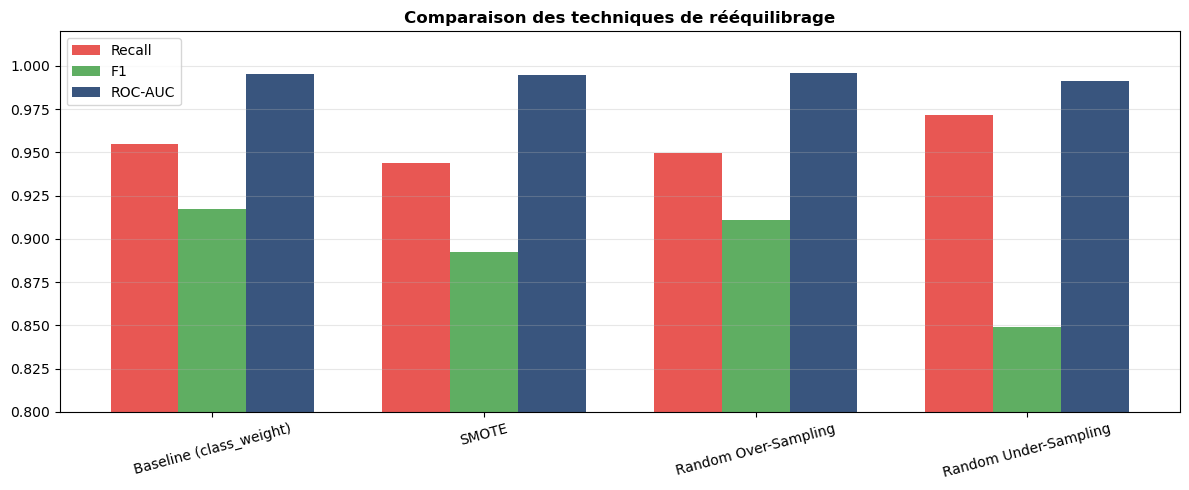


ANALYSE :
- Baseline (class_weight) : meilleur compromis Recall/F1 → modele retenu
- Random Under-Sampling   : meilleur Recall (0.97) mais F1 chute (perte info)
- SMOTE                   : performances légèrement inférieures au baseline
- Random Over-Sampling    : proche du baseline, meilleur ROC-AUC
- Conclusion : class_weight='balanced' suffit ici, pas besoin de rééchantillonnage



In [33]:
# CELLULE 11 - Visualisation comparaison rééquilibrage
fig, ax = plt.subplots(figsize=(12, 5))

x = np.arange(len(df_imbalance))
width = 0.25
metrics = ['Recall', 'F1', 'ROC-AUC']
colors = [COLOR_RED, COLOR_GREEN, COLOR_BLUE]

for i, (metric, color) in enumerate(zip(metrics, colors)):
    ax.bar(x + i*width, df_imbalance[metric], width, 
           label=metric, color=color, alpha=0.85)

ax.set_xticks(x + width)
ax.set_xticklabels(df_imbalance.index, rotation=15)
ax.set_ylim(0.8, 1.02)
ax.set_title('Comparaison des techniques de rééquilibrage', fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/imbalance_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("""
ANALYSE :
- Baseline (class_weight) : meilleur compromis Recall/F1 → modele retenu
- Random Under-Sampling   : meilleur Recall (0.97) mais F1 chute (perte info)
- SMOTE                   : performances légèrement inférieures au baseline
- Random Over-Sampling    : proche du baseline, meilleur ROC-AUC
- Conclusion : class_weight='balanced' suffit ici, pas besoin de rééchantillonnage
""")

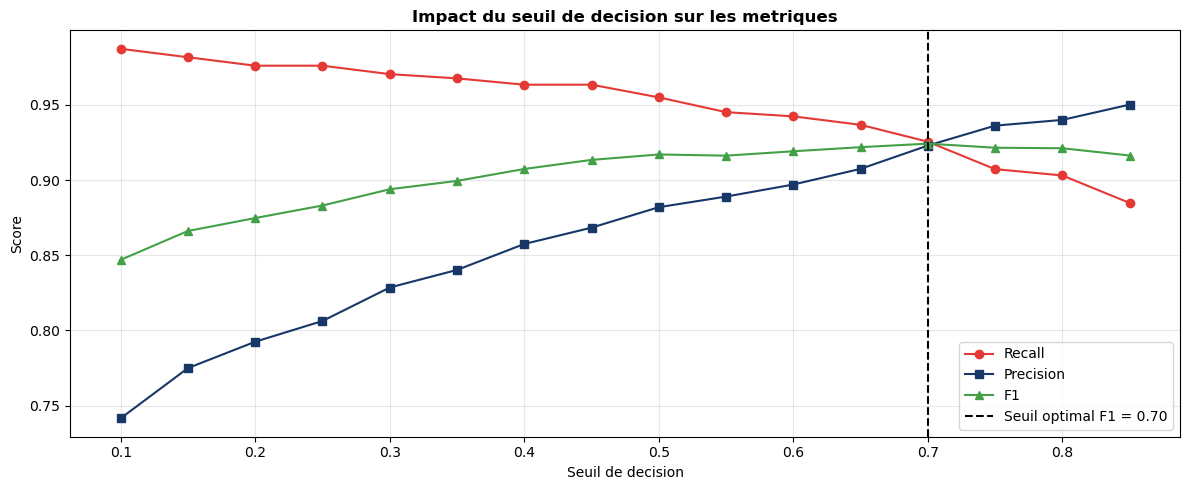

Seuil optimal (F1)    : 0.70
F1 au seuil optimal   : 0.9243
Recall au seuil opt.  : 0.9256


In [34]:
# CELLULE 12 - Optimisation du seuil de décision
from sklearn.metrics import precision_recall_curve

y_proba_xgb = xgb_base.predict_proba(X_test)[:,1]

thresholds = np.arange(0.1, 0.9, 0.05)
recalls, precisions, f1s = [], [], []

for threshold in thresholds:
    y_pred_t = (y_proba_xgb >= threshold).astype(int)
    recalls.append(recall_score(y_test, y_pred_t))
    precisions.append(precision_score(y_test, y_pred_t, zero_division=0))
    f1s.append(f1_score(y_test, y_pred_t, zero_division=0))

best_threshold_f1 = thresholds[np.argmax(f1s)]
best_threshold_recall = thresholds[np.argmax(recalls)]

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(thresholds, recalls, color=COLOR_RED, marker='o', label='Recall')
ax.plot(thresholds, precisions, color=COLOR_BLUE, marker='s', label='Precision')
ax.plot(thresholds, f1s, color=COLOR_GREEN, marker='^', label='F1')
ax.axvline(best_threshold_f1, color='black', linestyle='--', 
           label=f'Seuil optimal F1 = {best_threshold_f1:.2f}')
ax.set_xlabel('Seuil de decision')
ax.set_ylabel('Score')
ax.set_title('Impact du seuil de decision sur les metriques', fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/threshold_optimization.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Seuil optimal (F1)    : {best_threshold_f1:.2f}")
print(f"F1 au seuil optimal   : {max(f1s):.4f}")
print(f"Recall au seuil opt.  : {recalls[np.argmax(f1s)]:.4f}")

In [36]:
# CELLULE 13 - Validation croisée Stratified K-Fold
from sklearn.model_selection import StratifiedKFold, cross_validate
from xgboost import XGBClassifier
import numpy as np

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models_cv = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced', n_jobs=-1),
    'XGBoost': XGBClassifier(n_estimators=100, random_state=42, scale_pos_weight=16385/2848, eval_metric='logloss', verbosity=0),
}

print("VALIDATION CROISEE STRATIFIEE (5 folds)")
print("="*60)

cv_results = {}
for name, model_cv in models_cv.items():
    scores = cross_validate(model_cv, X_train, y_train, cv=skf,
                           scoring=['recall', 'f1', 'roc_auc'],
                           n_jobs=-1)
    cv_results[name] = {
        'Recall mean': scores['test_recall'].mean(),
        'Recall std': scores['test_recall'].std(),
        'F1 mean': scores['test_f1'].mean(),
        'F1 std': scores['test_f1'].std(),
        'ROC-AUC mean': scores['test_roc_auc'].mean(),
        'ROC-AUC std': scores['test_roc_auc'].std(),
    }
    print(f"\n{name}")
    print(f"  Recall  : {scores['test_recall'].mean():.4f} (+/- {scores['test_recall'].std():.4f})")
    print(f"  F1      : {scores['test_f1'].mean():.4f} (+/- {scores['test_f1'].std():.4f})")
    print(f"  ROC-AUC : {scores['test_roc_auc'].mean():.4f} (+/- {scores['test_roc_auc'].std():.4f})")

print("\nJustification : Stratified K-Fold preserve les proportions de classes (14.8% pannes) dans chaque fold.")

VALIDATION CROISEE STRATIFIEE (5 folds)

Logistic Regression
  Recall  : 0.8838 (+/- 0.0128)
  F1      : 0.7454 (+/- 0.0104)
  ROC-AUC : 0.9562 (+/- 0.0047)

Random Forest
  Recall  : 0.8683 (+/- 0.0113)
  F1      : 0.8932 (+/- 0.0070)
  ROC-AUC : 0.9930 (+/- 0.0011)

XGBoost
  Recall  : 0.9466 (+/- 0.0135)
  F1      : 0.9127 (+/- 0.0101)
  ROC-AUC : 0.9949 (+/- 0.0010)

Justification : Stratified K-Fold preserve les proportions de classes (14.8% pannes) dans chaque fold.
